# 单头自注意力模块

SelfAttention做的事本质上是:

序列中的每个token都去看序列里其他token, 在训练中判断自己应该关注谁, 然后把这些信息加权汇总得到新的表示.

下面是实现最小可用版本的自注意力的具体步骤:

1. 首先输入要求为一个序列x, 这里为了方便处理默认输入一个离散的数字序列, 序列中每个数字就是一个token.

2. 经过`nn.Embedding`将每个token映射到维度为`d_model`的空间中, 得到`x: (batch, seq_len, d_model)`.

3. 然后同一个输入x分别线性映射成`Q/K/V`, 虽然输入都是同一个x, 但是这里用了三个不同的线性层, 所以会得到三个不同的结果, 可以把它理解为每个token同时扮演了三种身份:
   - `Q (query)`: 倾向于表示当前token想找什么, 即查询信息, 当前token根据什么依据搜索别的token
   - `K (key)`: 倾向于表示当前token能被如何匹配, 即该token对外展示我是什么类型的信息
   - `V (value)`: 倾向于表示当前token真正提供给别人的内容, 注意力根据Q和K匹配出该看什么后, 在V里取对应的数据
4. `Q @ K.transpose(-2, -1)`这一段代码是计算每个位置的查询Q和所有位置的键K之间的相关性分数, 为避免计算出的结果太大, 所以后面要缩放, 除以`self.d_model ** 0.5`, 然后对最后一维进行`softmax`得到注意力权重`attn_w: (batch, seq_len, seq_len)`
   >  经典线性代数教材是列向量优先时$S=KQ$, 但这里是行向量优先, 行向量优先时$S=QK^T$, 两者在数学上完全等价

1. 用注意力权重对 `V` 加权求和得到`output: (batch, seq_len, d_model)`, 再经过输出层得到最终 logits.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import classification_report

class SelfAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model):
        super().__init__()
        # d_model: token 的隐藏维度
        # output_dim: 每个位置输出的类别数（例如实验1是1路位置分类，实验2是2路位置分类）
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None  # 缓存最近一次的注意力权重用于可视化
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        # (batch, seq_len) -> (batch, seq_len, d_model)
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x)
        K = self.w_k(x)
        V = self.w_v(x)
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_model ** 0.5 # @等价于torch.matmul函数 为方便使用@
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()  # 缓存
        output = attn_w @ V          # (batch, seq_len, d_model)
        return self.out(output)      # (batch, seq_len, output_dim)



## 注意力热力图可视化函数

该函数会绘制 batch 前 4 个样本的注意力矩阵, 帮助初学者观察:

- 每个 query 位置更关注哪些 key 位置

- 注意力是否集中到任务相关位置

In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens, title="Batch", cmap="Blues"):
    attn_w = attn_w[:4].detach().cpu().float()

    seq_len = attn_w.shape[1]
    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)

        labels = tokens[n]
        ax.set_xticks(range(seq_len))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(seq_len))
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_title(f"{title} [{n}]", fontsize=9)

        for i in range(seq_len):
            for j in range(seq_len):
                val = attn_w[n, i, j].item()
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if val > 0.6 else "black")

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()


# 实验1 找最大值下标

## 1. 数据集构建
我们选一个任务来把这个最简单的自注意力用起来, 从一堆乱序数字中找出最大值的下标

数据集构建: 
- 数据: 一堆乱序的数字 [[3, 2, 1, 5, 7],
                [1, 6, 2, 6, 1]]
- 标签: [4, 1]

实验目标: 我们把它定义为分类问题, 即输出最大的数字下标

为了测试这个模块的效果, 我们来构造一个数据集

In [3]:
def get_batch(batch, sql_len, low, high):
    # x: 随机整数序列，y: 最大值所在下标
    x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    y = torch.argmax(x, dim=-1)  # (batch_size,)
    return x, y
print(get_batch(2, 5, 0, 10))


(tensor([[7, 4, 7, 6, 2],
        [4, 2, 3, 6, 9]]), tensor([0, 4]))


## 2. 模型训练
输出层设置为 `output_dim=1`, 表示每个位置只输出1个logit.

模型输出形状是 `(batch, seq_len, 1)`, 压缩后变成 `(batch, seq_len)`.

用 `CrossEntropyLoss` 把 `seq_len` 视为类别数, 即预测哪个位置是最大值.

超参数设置为:
| vocab_size | d_model | lr | train_steps |
|-|-|-|-|
| 100 | 32 | 0.01 | 100 |

In [4]:

epochs = 100

model = SelfAttention(vocab_size=100, output_dim=1, d_model=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_batch(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x).squeeze(-1)  # (batch, seq_len, 1) -> (batch, seq_len)
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")


Epoch 10, Loss: 1.1920
Epoch 20, Loss: 0.4738
Epoch 30, Loss: 0.2631
Epoch 40, Loss: 0.1841
Epoch 50, Loss: 0.1301
Epoch 60, Loss: 0.0769
Epoch 70, Loss: 0.0861
Epoch 80, Loss: 0.0893
Epoch 90, Loss: 0.0703
Epoch 100, Loss: 0.0567


## 3. 评估结果

查看预测下标与真实下标, 并结合注意力图理解模型行为.

              precision    recall  f1-score   support

           0     0.9902    1.0000    0.9951       101
           1     0.9924    0.9924    0.9924       131
           2     0.9896    1.0000    0.9948        95
           3     0.9906    0.9906    0.9906       106
           4     1.0000    0.9796    0.9897        98
           5     0.9619    0.9902    0.9758       102
           6     1.0000    0.9907    0.9953       108
           7     0.9889    0.9889    0.9889        90
           8     0.9899    0.9800    0.9849       100
           9     1.0000    0.9892    0.9946        93

    accuracy                         0.9902      1024
   macro avg     0.9903    0.9902    0.9902      1024
weighted avg     0.9904    0.9902    0.9903      1024

------------------------------
input : [74, 68, 73, 21, 33, 41, 99, 99, 29, 1]
pred  : 6
target: 6
------------------------------
input : [65, 69, 43, 44, 80, 51, 98, 92, 13, 41]
pred  : 6
target: 6
------------------------------
input : [34

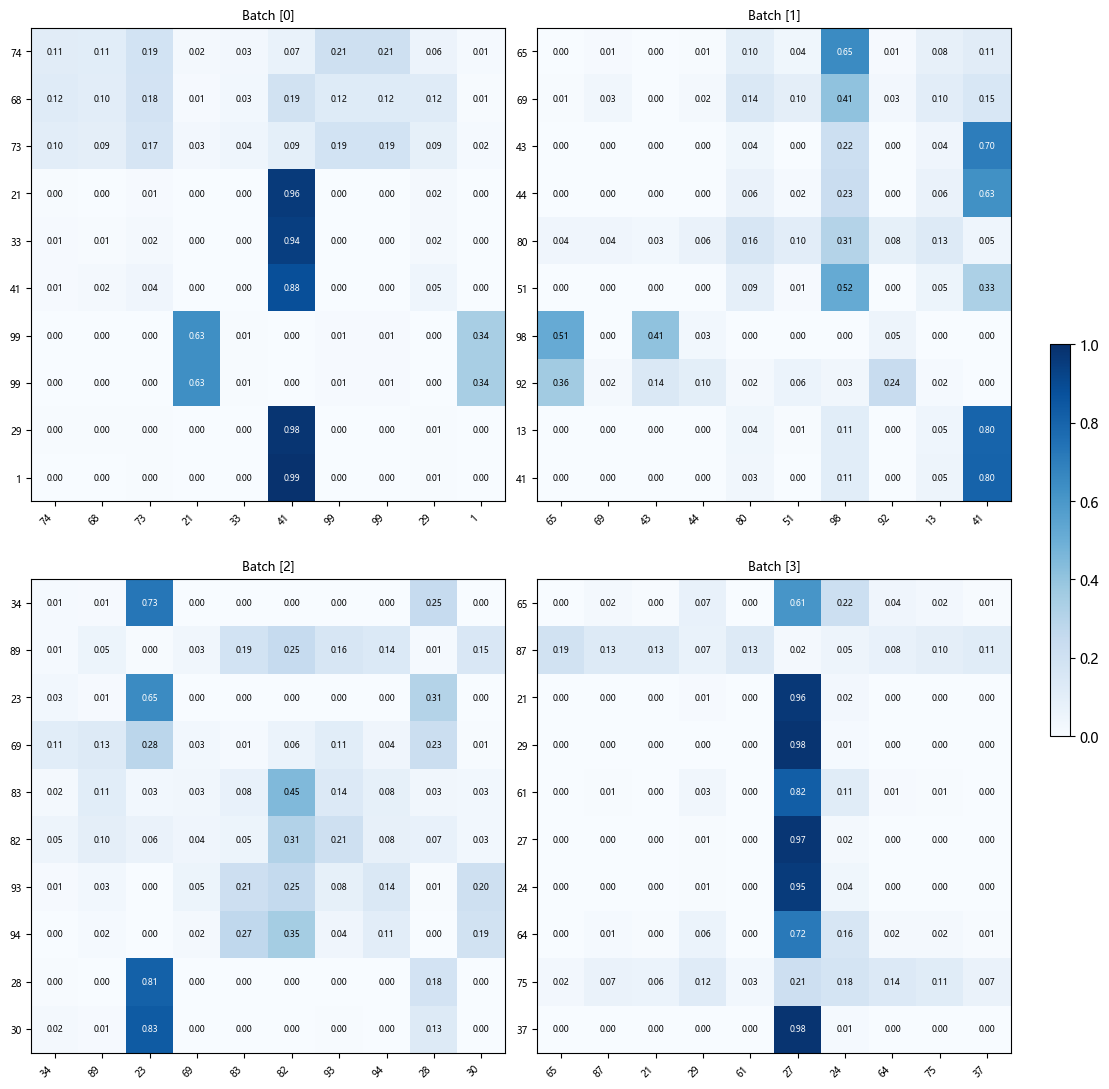

In [5]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_batch(1024, 10, 1, 100)
    eval_logits = model(eval_x).squeeze(-1)          # (1024, seq_len)
    eval_pred = eval_logits.argmax(dim=-1)           # (1024,)

    print(
        classification_report(
            eval_y.cpu().numpy(),
            eval_pred.cpu().numpy(),
            digits=4,
            zero_division=0
        )
    )

    test_x, test_y = get_batch(4, 10, 1, 100)

    logits = model(test_x).squeeze(-1) # (batch, seq_len, 1) -> (batch, seq_len)
    pred = torch.argmax(logits, dim=-1)  # logits转换成softmax概率 (batch, seq_len)

    for i in range(test_x.size(0)):
        print("-" * 30)
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].tolist()}")
        print(f"target: {test_y[i].tolist()}")
    
    sample_tokens = [[str(v) for v in row] for row in test_x.tolist()]
    plot_attention(model.attn_w, tokens=sample_tokens)


# 实验2 同时找最大值和最小值下标

## 1. 数据集构建

与实验1相比, 这里同一输入需要同时完成两个目标:

- 预测最大值位置

- 预测最小值位置


In [6]:
def get_batch_max_min(batch, sql_len, low, high):
    # y[:, 0] 是 max 下标，y[:, 1] 是 min 下标
    train_x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    max_y = torch.argmax(train_x, dim=-1)  # (batch_size,)
    min_y = torch.argmin(train_x, dim=-1)  # (batch_size,)
    return train_x, torch.stack([max_y, min_y], dim=-1)  # (batch_size, 2)
get_batch_max_min(2, 5, 0, 10)

(tensor([[4, 3, 2, 6, 2],
         [2, 2, 3, 4, 4]]),
 tensor([[3, 2],
         [3, 0]]))

## 2. 训练实验

因此输出层设为 `output_dim=2`, 分别对应 max/min 两路预测.

`pred` 形状是 `(batch, seq_len, 2)`: 

- `pred[:, :, 0]` 用来做最大值位置分类

- `pred[:, :, 1]` 用来做最小值位置分类

总损失为两路交叉熵之和.

超参数设置为:
| vocab_size | d_model | lr | train_steps |
|-|-|-|-|
| 100 | 32 | 0.01 | 100 |

In [9]:
epochs = 100
model = SelfAttention(vocab_size=100, output_dim=2, d_model=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_batch_max_min(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x)  # (batch, seq_len, 2)

    pred_max = pred[:, :, 0]  # (batch, seq_len)
    pred_min = pred[:, :, 1]  # (batch, seq_len)
    loss_max = criterion(pred_max, train_y[:, 0])
    loss_min = criterion(pred_min, train_y[:, 1])
    loss = loss_max + loss_min

    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(
            f"Epoch {i+1}, Loss: {loss.item():.4f}, "
            f"MaxLoss: {loss_max.item():.4f}, MinLoss: {loss_min.item():.4f}"
        )

Epoch 10, Loss: 3.1679, MaxLoss: 1.4661, MinLoss: 1.7017
Epoch 20, Loss: 1.4841, MaxLoss: 0.7633, MinLoss: 0.7208
Epoch 30, Loss: 0.8667, MaxLoss: 0.4515, MinLoss: 0.4152
Epoch 40, Loss: 0.5290, MaxLoss: 0.2788, MinLoss: 0.2501
Epoch 50, Loss: 0.3609, MaxLoss: 0.1654, MinLoss: 0.1955
Epoch 60, Loss: 0.2915, MaxLoss: 0.1356, MinLoss: 0.1559
Epoch 70, Loss: 0.2622, MaxLoss: 0.1256, MinLoss: 0.1366
Epoch 80, Loss: 0.2859, MaxLoss: 0.1528, MinLoss: 0.1331
Epoch 90, Loss: 0.1778, MaxLoss: 0.0937, MinLoss: 0.0841
Epoch 100, Loss: 0.1706, MaxLoss: 0.0911, MinLoss: 0.0795


## 3. 评估实验

同时打印 max/min 两路预测结果, 并观察注意力图是否出现对极值位置的关注模式

MAX task
              precision    recall  f1-score   support

           0     1.0000    0.9815    0.9907       108
           1     0.9706    1.0000    0.9851        99
           2     0.9916    0.9833    0.9874       120
           3     0.9655    0.9912    0.9782       113
           4     0.9626    0.9717    0.9671       106
           5     0.9792    0.9895    0.9843        95
           6     0.9903    0.9808    0.9855       104
           7     0.9770    0.9770    0.9770        87
           8     0.9663    0.9663    0.9663        89
           9     1.0000    0.9612    0.9802       103

    accuracy                         0.9805      1024
   macro avg     0.9803    0.9802    0.9802      1024
weighted avg     0.9807    0.9805    0.9805      1024

MIN task
              precision    recall  f1-score   support

           0     0.9646    1.0000    0.9820       109
           1     0.9912    0.9912    0.9912       114
           2     1.0000    1.0000    1.0000       120
      

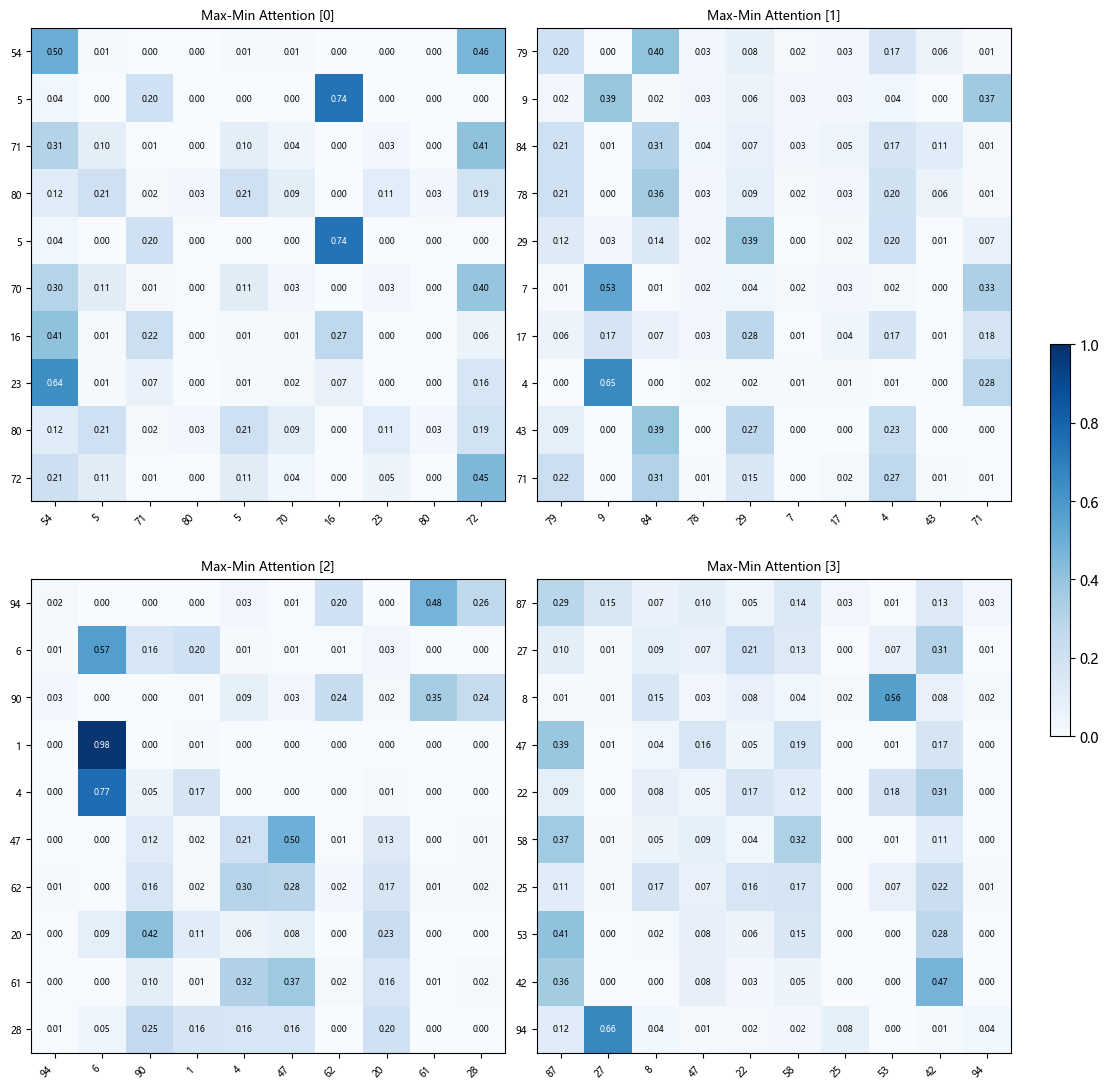

In [10]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_batch_max_min(1024, 10, 1, 100)
    eval_pred = model(eval_x)  # (batch, seq_len, 2)

    eval_pred_max = eval_pred[:, :, 0].argmax(dim=-1).cpu().numpy()
    eval_pred_min = eval_pred[:, :, 1].argmax(dim=-1).cpu().numpy()
    eval_y_max = eval_y[:, 0].cpu().numpy()
    eval_y_min = eval_y[:, 1].cpu().numpy()

    print("MAX task")
    print(classification_report(eval_y_max, eval_pred_max, digits=4, zero_division=0))

    print("MIN task")
    print(classification_report(eval_y_min, eval_pred_min, digits=4, zero_division=0))

    test_x, test_y = get_batch_max_min(4, 10, 1, 100)
    
    pred = model(test_x)
    pred_max = pred[:, :, 0].argmax(dim=-1)
    pred_min = pred[:, :, 1].argmax(dim=-1)

    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : [max={pred_max[i].item()}, min={pred_min[i].item()}]")
        print(f"target: [max={test_y[i,0].item()}, min={test_y[i,1].item()}]")
        print("-" * 30)
    
    sample_tokens = [[str(v) for v in row] for row in test_x.tolist()]
    plot_attention(model.attn_w, tokens=sample_tokens, title="Max-Min Attention")

